# VGAE on SNAP Facebook Ego Network

Trains a Variational Graph Auto-Encoder (Kipf & Welling, 2016) on the local
`data/facebook` SNAP ego-Facebook files and extracts μ (mean) latent vectors
as node embeddings that jointly encode topology + real anonymized profile features.

Reads raw files directly (no download): `facebook_combined.txt` for edges,
`facebook_ego/*.featnames` + `*.feat` + `*.egofeat` for features (unioned into
one global feature vocabulary across the 52 ego-networks, since the same
feature name has different local indices per ego-network).

Device: auto-selects CUDA → MPS → CPU.

In [5]:
import time
from pathlib import Path

import numpy as np
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, VGAE
from torch_geometric.utils import train_test_split_edges, to_undirected

In [6]:
def select_device() -> torch.device:
    if torch.cuda.is_available():
        dev = torch.device("cuda")
        print(f"[device]  CUDA  —  {torch.cuda.get_device_name(0)}")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        dev = torch.device("mps")
        print("[device]  MPS   —  Apple Silicon GPU")
    else:
        dev = torch.device("cpu")
        print("[device]  CPU")
    return dev


device = select_device()

[device]  MPS   —  Apple Silicon GPU


## Load data

Edges come from `facebook_combined.txt` (4039 nodes, 88234 undirected edges).
Features come from the 52 ego-network `.feat`/`.featnames`/`.egofeat` files:
each ego-network has its own local feature indexing, so feature *names* are
unioned into one global vocabulary and every node's bits are placed at their
global index.

In [7]:
DATA_DIR = Path("data/facebook")
EGO_DIR = DATA_DIR / "facebook_ego"
NUM_NODES = 4039


def load_facebook_features(ego_dir: Path, num_nodes: int):
    """Union per-ego-network feature namespaces into one global feature matrix."""
    vocab: dict[str, int] = {}
    node_feats: list[dict[int, float]] = [dict() for _ in range(num_nodes)]

    ego_ids = sorted(int(p.stem) for p in ego_dir.glob("*.featnames"))
    for ego_id in ego_ids:
        with open(ego_dir / f"{ego_id}.featnames") as f:
            local_names = [line.strip().split(" ", 1)[1] for line in f]

        local_to_global = []
        for name in local_names:
            if name not in vocab:
                vocab[name] = len(vocab)
            local_to_global.append(vocab[name])

        with open(ego_dir / f"{ego_id}.feat") as f:
            for line in f:
                vals = line.split()
                node_id = int(vals[0])
                for local_idx, bit in enumerate(vals[1:]):
                    if bit == "1":
                        node_feats[node_id][local_to_global[local_idx]] = 1.0

        with open(ego_dir / f"{ego_id}.egofeat") as f:
            bits = f.readline().split()
            for local_idx, bit in enumerate(bits):
                if bit == "1":
                    node_feats[ego_id][local_to_global[local_idx]] = 1.0

    num_feats = len(vocab)
    x = np.zeros((num_nodes, num_feats), dtype=np.float32)
    for node_id, feats in enumerate(node_feats):
        for idx in feats:
            x[node_id, idx] = 1.0
    return torch.from_numpy(x), vocab


print("[data]    parsing ego-network features …")
x, feat_vocab = load_facebook_features(EGO_DIR, NUM_NODES)
print(f"[data]    global feature vocab size: {len(feat_vocab)}")

edges = np.loadtxt(DATA_DIR / "facebook_combined.txt", dtype=np.int64)
edge_index = to_undirected(torch.from_numpy(edges.T), num_nodes=NUM_NODES)
print(f"[data]    nodes: {NUM_NODES}  |  edges: {edge_index.size(1) // 2}  |  features: {x.size(1)}")

data = Data(x=x, edge_index=edge_index, num_nodes=NUM_NODES)
data = train_test_split_edges(data)
num_features = x.size(1)

[data]    parsing ego-network features …
[data]    global feature vocab size: 1406
[data]    nodes: 4039  |  edges: 88234  |  features: 1406


/var/folders/dd/210gw5zj5mqf9n91h2vn_5000000gn/T/ipykernel_45787/2444916682.py:53: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  data = train_test_split_edges(data)


## Encoder

Two shared GCN layers followed by two parallel projection heads that output
the mean (μ) and log-variance (logσ²) of the variational posterior
q(z|X, A). The μ vector is the embedding extracted at inference.

In [8]:
class VGAEEncoder(torch.nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv_mu = GCNConv(hidden_channels, out_channels)
        self.conv_logstd = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        mu = self.conv_mu(h, edge_index)
        logstd = self.conv_logstd(h, edge_index)
        return mu, logstd

## Train

In [9]:
def train_vgae(data, num_features, hidden_dim, embed_dim, epochs, lr, device, patience=30):
    encoder = VGAEEncoder(num_features, hidden_dim, embed_dim)
    model = VGAE(encoder).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    x = data.x.to(device)
    train_pos = data.train_pos_edge_index.to(device)

    best_auc = 0.0
    best_state = None
    epochs_since_best = 0

    model.train()
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        z = model.encode(x, train_pos)
        loss = model.recon_loss(z, train_pos)
        loss = loss + (1 / data.num_nodes) * model.kl_loss()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            z_eval = model.encode(x, train_pos)
            auc, ap = model.test(
                z_eval,
                data.val_pos_edge_index.to(device),
                data.val_neg_edge_index.to(device),
            )
        model.train()

        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_since_best = 0
        else:
            epochs_since_best += 1

        if epoch % 50 == 0 or epoch == 1:
            elapsed = time.time() - t0
            print(
                f"  epoch {epoch:4d}/{epochs}  |  loss {loss.item():.4f}  "
                f"|  val AUC {auc:.4f}  AP {ap:.4f}  |  {elapsed:.1f}s"
            )

        if epochs_since_best >= patience:
            print(f"  early stop at epoch {epoch}  |  best val AUC {best_auc:.4f} (epoch {epoch - patience})")
            break

    model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        z_test = model.encode(x, train_pos)
        auc, ap = model.test(
            z_test,
            data.test_pos_edge_index.to(device),
            data.test_neg_edge_index.to(device),
        )
    print(f"\n[test]    AUC {auc:.4f}  |  AP {ap:.4f}")
    return model

In [6]:
HIDDEN_DIM = 128
EMBED_DIM = 32
EPOCHS = 300
LR = 0.01

print(f"[train]   hidden={HIDDEN_DIM}  embed_dim={EMBED_DIM}  epochs={EPOCHS}  lr={LR}\n")
model = train_vgae(data, num_features, HIDDEN_DIM, EMBED_DIM, EPOCHS, LR, device)

[train]   hidden=128  embed_dim=32  epochs=300  lr=0.01

  epoch    1/300  |  loss 4.8041  |  val AUC 0.8408  AP 0.8484  |  4.0s
  epoch   50/300  |  loss 0.8331  |  val AUC 0.9849  AP 0.9842  |  41.9s
  epoch  100/300  |  loss 0.8020  |  val AUC 0.9888  AP 0.9881  |  78.0s
  epoch  150/300  |  loss 0.7927  |  val AUC 0.9904  AP 0.9897  |  114.3s
  epoch  200/300  |  loss 0.7864  |  val AUC 0.9906  AP 0.9901  |  150.5s
  early stop at epoch 209  |  best val AUC 0.9907 (epoch 179)

[test]    AUC 0.9905  |  AP 0.9893


## Extract embeddings

Single forward pass through the trained encoder — returns the μ vectors,
shape `[num_nodes, EMBED_DIM]`, ready for downstream clustering.

In [7]:
@torch.no_grad()
def extract_embeddings(model, data, device) -> torch.Tensor:
    model.eval()
    x = data.x.to(device)
    edge_index = data.train_pos_edge_index.to(device)
    mu, _ = model.encoder(x, edge_index)
    return mu.cpu()


embeddings = extract_embeddings(model, data, device)
print(f"[embed]   shape: {list(embeddings.shape)}")

[embed]   shape: [4039, 32]


In [8]:
OUT_DIR = Path("output_ego_facebook")
OUT_DIR.mkdir(exist_ok=True)

emb_path = OUT_DIR / "embeddings.pt"
model_path = OUT_DIR / "model.pt"
numpy_path = OUT_DIR / "embeddings.npy"

torch.save(embeddings, emb_path)
torch.save(model.state_dict(), model_path)
np.save(numpy_path, embeddings.numpy())

print(f"[saved]   {emb_path}")
print(f"[saved]   {numpy_path}")
print(f"[saved]   {model_path}")

[saved]   output_ego_facebook/embeddings.pt
[saved]   output_ego_facebook/embeddings.npy
[saved]   output_ego_facebook/model.pt


In [9]:
norms = embeddings.norm(dim=1)
print(f"[sanity]  embedding norm  — mean: {norms.mean():.3f}  std: {norms.std():.3f}  min: {norms.min():.3f}  max: {norms.max():.3f}")

S = torch.linalg.svdvals(embeddings)
p = S / S.sum()
eff_rank = torch.exp(-torch.sum(p * torch.log(p + 1e-12)))
print(
    f"[sanity]  effective rank  — {eff_rank:.1f} / {EMBED_DIM}  "
    f"({'good spread' if eff_rank > EMBED_DIM * 0.5 else 'potential collapse — consider tuning'})"
)

[sanity]  embedding norm  — mean: 1.649  std: 0.666  min: 0.149  max: 5.875
[sanity]  effective rank  — 19.1 / 32  (good spread)


## UMAP projection

2D projection of the embeddings for visual inspection — clusters here should
roughly correspond to Facebook "circles"/communities if the embeddings
captured meaningful structure. Colored by node degree since no ground-truth
labels are available for this dataset.

/opt/anaconda3/envs/MPS/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


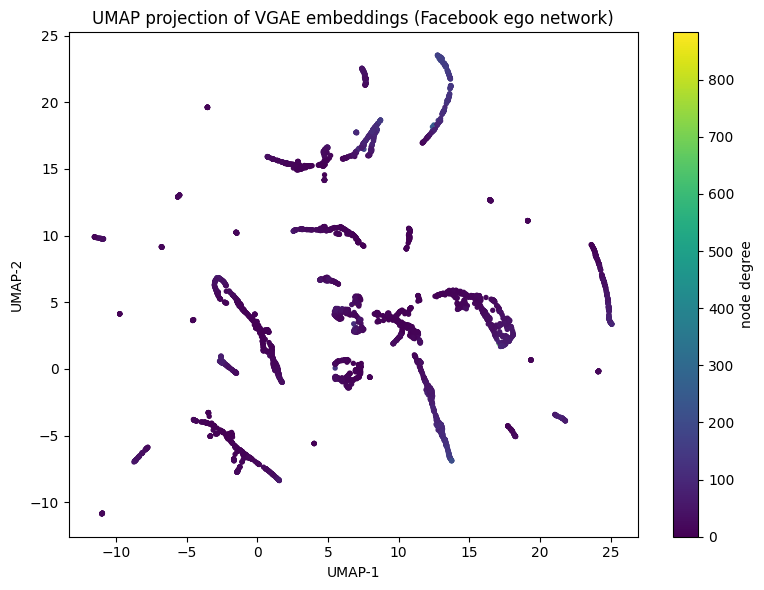

In [10]:
import umap
import matplotlib.pyplot as plt
from torch_geometric.utils import degree

OUT_DIR = Path("output_ego_facebook")
saved_embeddings = np.load(OUT_DIR / "embeddings.npy")

reducer = umap.UMAP(n_components=2, random_state=42)
proj = reducer.fit_transform(saved_embeddings)

node_degree = degree(data.train_pos_edge_index[0], num_nodes=NUM_NODES).numpy()

plt.figure(figsize=(8, 6))
sc = plt.scatter(proj[:, 0], proj[:, 1], c=node_degree, cmap="viridis", s=8)
plt.colorbar(sc, label="node degree")
plt.title("UMAP projection of VGAE embeddings (Facebook ego network)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()